In [ ]:
import re


def parse_oha_latencies(file_path):
    with open(file_path, "r") as f:
        content = f.read()

    def extract(percent):
        match = re.search(rf"{percent}\.00% in ([\d.]+) sec", content)
        if not match:
            raise ValueError(f"Average latency not found in {file_path}")
        return float(match.group(1)) * 1000

    p50 = extract(50)
    p99 = extract(99)

    return p50, p99

In [2]:
def parse_logs(file_path):
    cold_init = 0.0
    cold_duration = 0.0
    warm_durations = []

    with open(file_path, "r") as f:
        for line in f:
            # Cold start (has Init Duration)
            if "Init Duration" in line:
                init_match = re.search(r"Init Duration:\s+([\d.]+)\s+ms", line)
                dur_match = re.search(r"Duration:\s+([\d.]+)\s+ms", line)

                if init_match and dur_match:
                    cold_init = float(init_match.group(1))
                    cold_duration = float(dur_match.group(1))

            else:
                # Warm invocation
                dur_match = re.search(r"Duration:\s+([\d.]+)\s+ms", line)
                if dur_match:
                    warm_durations.append(float(dur_match.group(1)))

    warm_avg = sum(warm_durations) / len(warm_durations)

    return cold_init, cold_duration, warm_avg

In [3]:
zip_warm_latency, zip_cold_latency = parse_oha_latencies(
    "../results/scenario-a-zip.txt"
)
cont_warm_latency, cont_cold_latency = parse_oha_latencies(
    "../results/scenario-a-container.txt"
)

zip_cold_init, zip_cold_dur, zip_warm_dur = parse_logs(
    "../results/scenario-a-zip-logs.txt"
)
cont_cold_init, cont_cold_dur, cont_warm_dur = parse_logs(
    "../results/scenario-a-container-logs.txt"
)

In [8]:
# Warm: RTT = total - duration
zip_rtt_warm = zip_warm_latency - zip_warm_dur
cont_rtt_warm = cont_warm_latency - cont_warm_dur

# Cold: RTT = total - init - duration
zip_rtt_cold = zip_cold_latency - zip_cold_init - zip_cold_dur
cont_rtt_cold = cont_cold_latency - cont_cold_init - cont_cold_dur

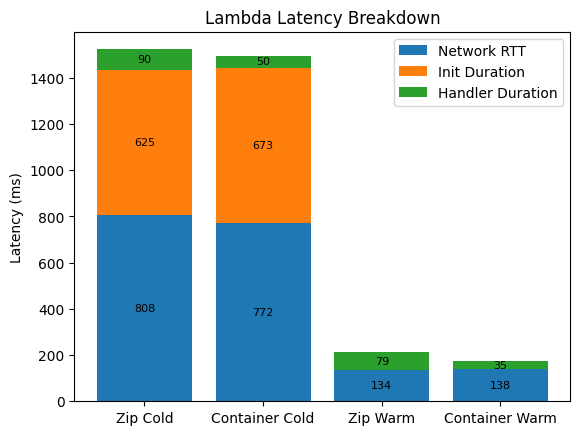

In [ ]:
from matplotlib.container import BarContainer
import matplotlib.pyplot as plt


def add_labels(bars: BarContainer, values: list[float], bottoms=None):
    for i, bar in enumerate(bars):
        height = values[i]
        if height <= 0:
            continue

        if bottoms:
            y = bottoms[i] + height / 2
        else:
            y = height / 2

        plt.text(
            bar.get_x() + bar.get_width() / 2,
            y,
            f"{height:.0f}",
            ha="center",
            va="center",
            fontsize=8,
        )


labels = ["Zip Cold", "Container Cold", "Zip Warm", "Container Warm"]
network = [zip_rtt_cold, cont_rtt_cold, zip_rtt_warm, cont_rtt_warm]
init = [zip_cold_init, cont_cold_init, 0, 0]
handler = [zip_cold_dur, cont_cold_dur, zip_warm_dur, cont_warm_dur]

x = range(len(labels))

plt.figure()
bars1 = plt.bar(x, network, label="Network RTT")
bars2 = plt.bar(x, init, bottom=network, label="Init Duration")
bottom_handler = [network[i] + init[i] for i in range(len(network))]
bars3 = plt.bar(x, handler, bottom=bottom_handler, label="Handler Duration")

plt.xticks(x, labels)
plt.ylabel("Latency (ms)")
plt.title("Lambda Latency Breakdown")
plt.legend()


add_labels(bars1, network)
add_labels(bars2, init, bottoms=network)
add_labels(bars3, handler, bottoms=bottom_handler)

plt.show()